# A3: Self-Supervised Learning — SimCLR · DINO · MAE

**DL-AIT Assignment 3 | Student: Dechathon Niamsa-ard [st126235]**

This **stand-alone** notebook implements and compares the three major families of
self-supervised visual representation learning on CIFAR-10, **without any labels**
during pre-training:

| Family | Model | Key idea |
|---|---|---|
| Contrastive | **SimCLR** (2020) | pull two augmented views together, push others apart (NT-Xent) |
| Self-distillation | **DINO** (2021) | student predicts an EMA teacher; **centering** prevents collapse |
| Reconstruction | **MAE** (2022) | mask 75% of patches and reconstruct them |

It trains/loads each model, runs the required **ablations** (DINO: no-centering,
no-local-crops; MAE: mask ratio ∈ {0.25, 0.50, 0.75}), produces every
**visualization** (loss curves, DINO `center.norm()`, MAE reconstruction grid,
DINO attention maps, t-SNE), and answers **all exercises** at the end.

**Evaluation — Linear Probing:** freeze the encoder, train a single linear layer on
top with labels. High accuracy ⇒ the encoder learned linearly-separable, semantic
features with no labels. Random baseline ≈ 10% (10 classes).

> **How to run.** Set `LOAD_PRETRAINED = True` (default) to load the checkpoints
> produced by `scripts.sh` / `scripts.ps1` and reproduce all tables/figures in minutes.
> Set it to `False` to train everything from scratch (hours, GPU recommended).

**Papers:** [SimCLR](https://arxiv.org/abs/2002.05709) ·
[DINO](https://arxiv.org/abs/2104.14294) · [MAE](https://arxiv.org/abs/2111.06377)

## 0 · Setup & configuration

GPU is used automatically when available (this work was produced on an RTX 5060 Ti
with PyTorch `cu128`). Seeds are fixed for reproducibility.

In [1]:
import json, math, os, random, time, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import timm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")  # silence benign deprecation / nested-tensor notes

# ---- Reproducibility & device ----
def set_seed(seed=42):
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    np.random.seed(seed); random.seed(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "|", torch.cuda.get_device_name(0) if device.type=="cuda" else "CPU")

# ---- Locate repo root (works whether run from notebooks/ or repo root) ----
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA_DIR, SAVED_DIR = ROOT / "data", ROOT / "saved"
RESULTS_DIR, FIGURES_DIR = ROOT / "results", ROOT / "figures"
for d in (DATA_DIR, SAVED_DIR, RESULTS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Run configuration ----
LOAD_PRETRAINED = True   # load checkpoints from scripts.sh / scripts.ps1 (fast). False -> train here.
SAVE_OUTPUTS = False     # True -> also write figures/*.png + results/results.json to disk (like the CLI)
AMP = True               # bfloat16 mixed precision on CUDA
NUM_WORKERS = 0          # 0 is safest in notebooks (no multiprocessing); raise for speed
EPOCHS = {"simclr": 30, "dino": 50, "mae_main": 50, "mae_ablation": 5}

# ---- CIFAR-10 constants ----
CLASSES = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
CIFAR_MEAN, CIFAR_STD = [0.4914,0.4822,0.4465], [0.2023,0.1994,0.2010]
MAE_MEAN,  MAE_STD     = [0.4914,0.4822,0.4465], [0.247,0.243,0.261]
EVAL_TF = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])

import contextlib
def amp_ctx():
    return torch.autocast("cuda", dtype=torch.bfloat16) if (AMP and device.type=="cuda") else contextlib.nullcontext()

# ---- Authoritative metrics from the full run (scripts.sh / scripts.ps1) ----
RESULTS = json.loads((RESULTS_DIR/"results.json").read_text()) if (RESULTS_DIR/"results.json").exists() else {}
print("Loaded results.json keys:", list(RESULTS.keys()) if RESULTS else "(none yet — run scripts.sh / scripts.ps1)")

# ---- Replay recorded per-epoch training logs ----------------------------------
# Checkpoints were produced by scripts.sh / scripts.ps1; results.json stores the
# real per-epoch history. When LOAD_PRETRAINED loads a checkpoint, we replay that
# history below so the notebook shows the same epoch-by-epoch training log as a
# live run (identical to the print() lines inside each train_* loop).
def replay_training_log(rec, kind="loss"):
    losses = rec.get("losses", []); cnorms = rec.get("center_norms")
    for i, l in enumerate(losses, 1):
        if kind == "dino" and cnorms:
            print(f"  epoch {i:02d} loss {l:.4f} center_norm {cnorms[i-1]:.4f}")
        elif kind == "recon":
            print(f"  epoch {i:02d} recon {l:.4f}")
        else:
            print(f"  epoch {i:02d} loss {l:.4f}")

Device: cuda | NVIDIA GeForce RTX 5060 Ti
Loaded results.json keys: ['meta', 'simclr', 'dino_default', 'dino_no_centering', 'dino_no_local', 'mae_075_main', 'mae_ablation']


---
## 1 · SimCLR — Contrastive Learning

Two augmented views of the same image should be close in feature space; views from
different images should be far apart.

```
x ─[aug]─▶ x_i ─[Encoder f]─▶ h_i ─[Projector g]─▶ z_i ─┐
  └[aug]─▶ x_j ─[Encoder f]─▶ h_j ─[Projector g]─▶ z_j ─┴▶ NT-Xent loss
```

The loss is computed on the projection `z`; downstream linear eval uses the encoder
output `h` (the projector absorbs augmentation-specific nuisance information).
NT-Xent, for batch `N`, treats the other `2N-2` views as negatives:

$$\ell_{i,j} = -\log \frac{\exp(\mathrm{sim}(z_i,z_j)/\tau)}{\sum_{k\neq i}\exp(\mathrm{sim}(z_i,z_k)/\tau)}$$

In [2]:
class SimCLRAugmentation:
    def __init__(self, image_size=32):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter(0.4,0.4,0.4,0.1)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=3),
            transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])
    def __call__(self, x): return self.transform(x), self.transform(x)

class CIFAR10SSL(Dataset):
    def __init__(self, train=True):
        self.dataset = torchvision.datasets.CIFAR10(str(DATA_DIR), train=train, download=True)
        self.augment = SimCLRAugmentation()
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]; xi, xj = self.augment(img); return xi, xj, label

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__(); self.temperature = temperature
    def forward(self, z_i, z_j):
        N = z_i.shape[0]
        z_i, z_j = F.normalize(z_i, dim=1), F.normalize(z_j, dim=1)
        z = torch.cat([z_i, z_j], dim=0)
        sim = torch.mm(z, z.T) / self.temperature
        sim = sim.masked_fill(torch.eye(2*N, dtype=torch.bool, device=z.device), float("-inf"))
        labels = torch.cat([torch.arange(N, 2*N), torch.arange(0, N)]).to(z.device)
        return F.cross_entropy(sim, labels)

class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = torchvision.models.resnet18(weights=None)
        resnet.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        resnet.maxpool = nn.Identity()
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])
        self.projector = nn.Sequential(nn.Linear(512,512), nn.ReLU(), nn.Linear(512,128))
    def forward(self, x_i, x_j):
        h_i = torch.flatten(self.encoder(x_i), 1); h_j = torch.flatten(self.encoder(x_j), 1)
        return self.projector(h_i), self.projector(h_j), h_i, h_j

In [3]:
def train_simclr(epochs, lr=3e-4):
    set_seed(42)
    loader = DataLoader(CIFAR10SSL(), batch_size=256, shuffle=True, num_workers=NUM_WORKERS,
                        drop_last=True, pin_memory=True)
    model = SimCLR().to(device); crit = NTXentLoss(0.5)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    losses, times = [], []
    for ep in range(epochs):
        model.train(); cur=[]; t0=time.time()
        for x_i, x_j, _ in tqdm(loader, desc=f"SimCLR {ep+1}/{epochs}", leave=False):
            x_i, x_j = x_i.to(device), x_j.to(device)
            with amp_ctx(): z_i, z_j, _, _ = model(x_i, x_j); loss = crit(z_i, z_j)
            opt.zero_grad(); loss.backward(); opt.step(); cur.append(loss.item())
        losses.append(float(np.mean(cur))); times.append(time.time()-t0)
        print(f"  epoch {ep+1:02d} loss {losses[-1]:.4f}")
    return model, {"losses": losses, "time_per_epoch": float(np.mean(times))}

simclr = SimCLR().to(device)
if LOAD_PRETRAINED and (SAVED_DIR/"simclr.pt").exists():
    simclr.load_state_dict(torch.load(SAVED_DIR/"simclr.pt", map_location=device))
    print("Loaded saved/simclr.pt  (replaying recorded training log)")
    replay_training_log(RESULTS.get("simclr", {}))
else:
    simclr, hist = train_simclr(EPOCHS["simclr"]); torch.save(simclr.state_dict(), SAVED_DIR/"simclr.pt")
    RESULTS.setdefault("simclr", {}).update(hist)
simclr.eval()
for p in simclr.encoder.parameters(): p.requires_grad = False

Loaded saved/simclr.pt  (replaying recorded training log)
  epoch 01 loss 5.4123
  epoch 02 loss 5.2190
  epoch 03 loss 5.1408
  epoch 04 loss 5.0837
  epoch 05 loss 5.0466
  epoch 06 loss 5.0145
  epoch 07 loss 4.9911
  epoch 08 loss 4.9757
  epoch 09 loss 4.9604
  epoch 10 loss 4.9448
  epoch 11 loss 4.9369
  epoch 12 loss 4.9234
  epoch 13 loss 4.9161
  epoch 14 loss 4.9056
  epoch 15 loss 4.9036
  epoch 16 loss 4.8957
  epoch 17 loss 4.8908
  epoch 18 loss 4.8861
  epoch 19 loss 4.8823
  epoch 20 loss 4.8737
  epoch 21 loss 4.8691
  epoch 22 loss 4.8719
  epoch 23 loss 4.8635
  epoch 24 loss 4.8602
  epoch 25 loss 4.8587
  epoch 26 loss 4.8568
  epoch 27 loss 4.8528
  epoch 28 loss 4.8497
  epoch 29 loss 4.8452
  epoch 30 loss 4.8431


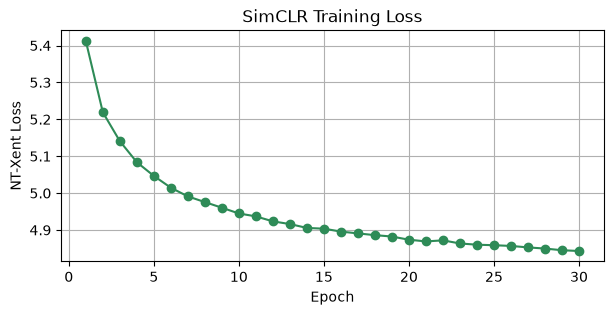

In [4]:
# SimCLR training-loss curve (from the full run's recorded history)
def plot_loss(key, title, color, ylabel):
    losses = RESULTS.get(key, {}).get("losses")
    if not losses:
        print(f"No loss history for {key} yet (run scripts.sh / scripts.ps1)."); return
    plt.figure(figsize=(7,3))
    plt.plot(range(1,len(losses)+1), losses, marker="o", color=color)
    plt.title(title); plt.xlabel("Epoch"); plt.ylabel(ylabel); plt.grid(True); plt.show()

plot_loss("simclr", "SimCLR Training Loss", "seagreen", "NT-Xent Loss")

### Linear evaluation helper (used by all three models)

We extract frozen features **once** and train a linear probe on the cached features
— equivalent to the standard protocol but much faster. The probe returns test
accuracy and the test-set embeddings (reused for t-SNE).

> The *authoritative* numbers in the exercise tables below come from
> `results/results.json` (the full training run via `scripts.sh` / `scripts.ps1`, which
> follows the lab's protocol — 10 epochs, re-extracting features each epoch, and **augmented** training
> crops for MAE). The "live" probe printed here is a faster, no-augmentation
> approximation, so its numbers may differ slightly (most for MAE, whose full-run
> probe is augmented).

In [5]:
def eval_loaders(mae=False, augment_train=False):
    test_tf = EVAL_TF if not mae else transforms.Compose([transforms.ToTensor(), transforms.Normalize(MAE_MEAN, MAE_STD)])
    if augment_train:   # lab cell 31: the MAE probe trains on RandomCrop+flip-augmented images
        train_tf = transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
                                       transforms.ToTensor(), transforms.Normalize(MAE_MEAN, MAE_STD)])
    else:               # lab cells 9/19: SimCLR/DINO probes use the plain eval transform (no augmentation)
        train_tf = test_tf
    tr = torchvision.datasets.CIFAR10(str(DATA_DIR), train=True,  download=True, transform=train_tf)
    te = torchvision.datasets.CIFAR10(str(DATA_DIR), train=False, download=True, transform=test_tf)
    return (DataLoader(tr, 256, shuffle=True,  num_workers=NUM_WORKERS),
            DataLoader(te, 256, shuffle=False, num_workers=NUM_WORKERS))

@torch.no_grad()
def extract(feature_fn, loader):
    fs, ys = [], []
    for imgs, y in tqdm(loader, desc="extract", leave=False):
        fs.append(feature_fn(imgs.to(device)).cpu()); ys.append(y)
    return torch.cat(fs), torch.cat(ys)

def linear_probe(feature_fn, mae=False, epochs=10, bs=256, lr=1e-3):
    # Matches lab_note + CLI linear_eval: 10 epochs, Adam(lr=1e-3), no weight_decay.
    # MAE additionally augments the probe's training data (lab cell 31), so its features
    # are re-extracted each epoch; SimCLR/DINO use cached, un-augmented features (lab 9/19).
    trl, tel = eval_loaders(mae=mae, augment_train=mae)
    Xte, yte = extract(feature_fn, tel)
    clf = opt = None
    if mae:
        for _ in range(epochs):
            for imgs, y in tqdm(trl, desc="probe", leave=False):
                with torch.no_grad(): h = feature_fn(imgs.to(device))
                if clf is None:
                    clf = nn.Linear(h.shape[1], 10).to(device); opt = torch.optim.Adam(clf.parameters(), lr=lr)
                clf.train(); opt.zero_grad()
                F.cross_entropy(clf(h), y.to(device)).backward(); opt.step()
    else:
        Xtr, ytr = extract(feature_fn, trl); Xtr, ytr = Xtr.to(device), ytr.to(device)
        clf = nn.Linear(Xtr.shape[1], 10).to(device); opt = torch.optim.Adam(clf.parameters(), lr=lr)
        n = Xtr.shape[0]
        for _ in range(epochs):
            perm = torch.randperm(n, device=device); clf.train()
            for i in range(0, n, bs):
                idx = perm[i:i+bs]; opt.zero_grad()
                F.cross_entropy(clf(Xtr[idx]), ytr[idx]).backward(); opt.step()
    clf.eval()
    with torch.no_grad():
        acc = (clf(Xte.to(device)).argmax(1).cpu() == yte).float().mean().item()*100
    return acc, Xte, yte

simclr_acc, simclr_emb, simclr_lbl = linear_probe(lambda x: torch.flatten(simclr.encoder(x),1))
print(f"SimCLR linear-probe test accuracy (live): {simclr_acc:.2f}%")
print(f"SimCLR linear-eval accuracy (full run):  {RESULTS.get('simclr',{}).get('linear_acc','?')}")

extract:   0%|          | 0/40 [00:00<?, ?it/s]

extract:   0%|          | 0/196 [00:00<?, ?it/s]

SimCLR linear-probe test accuracy (live): 72.95%
SimCLR linear-eval accuracy (full run):  73.11999999999999


---
## From SimCLR to DINO

SimCLR needs a **huge batch** for enough negatives (original paper: 4096).
**MoCo** decouples this with a memory queue + momentum encoder. **BYOL** removes
negatives entirely (EMA target + predictor) but risks **mode collapse** — outputting
the same vector for every image. **DINO** replaces BYOL's opaque asymmetry with one
interpretable operation: **centering**.

Without centering the teacher softmax lets one dimension dominate for every image
(`[0.98, 0.01, …]`), so the student trivially outputs that constant → collapse.
Centering subtracts a running mean `c` from the teacher logits before softmax; if a
dimension dominates, `c` grows to cancel it, forcing the distribution to spread:

$$z_{\text{corrected}} = z_{\text{teacher}} - c, \qquad c \leftarrow m\,c + (1-m)\,\overline{z_{\text{teacher}}}$$

A temperature asymmetry reinforces this (teacher τ=0.04 sharp, student τ=0.1 softer).

## 2 · DINO — Self-Distillation

- **Multi-crop:** teacher sees 2 global crops; student sees globals + locals and must
  predict global context from local views.
- **EMA teacher:** `teacher = m·teacher + (1-m)·student` (no backprop through teacher).
- **Centering:** subtract running mean `c` from teacher logits → prevents collapse.
- **Emergent attention:** the `[CLS]` token learns to attend to foreground objects
  with zero segmentation labels.

In [6]:
class DINOAugmentation:
    def __init__(self, image_size=32, n_local=4):
        norm = transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
        fj = [transforms.RandomHorizontalFlip(),
              transforms.RandomApply([transforms.ColorJitter(0.4,0.4,0.2,0.1)], p=0.8),
              transforms.RandomGrayscale(p=0.2)]
        self.g = transforms.Compose([transforms.RandomResizedCrop(image_size, scale=(0.4,1.0)), *fj, transforms.ToTensor(), norm])
        self.l = transforms.Compose([transforms.RandomResizedCrop(image_size, scale=(0.05,0.4)), *fj, transforms.ToTensor(), norm])
        self.n_local = n_local
    def __call__(self, img):
        return [self.g(img), self.g(img)] + [self.l(img) for _ in range(self.n_local)]

class CIFAR10DINO(Dataset):
    def __init__(self, train=True, n_local=4):
        self.dataset = torchvision.datasets.CIFAR10(str(DATA_DIR), train=train, download=True)
        self.augment = DINOAugmentation(n_local=n_local)
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]; return self.augment(img), label

def dino_collate(batch):
    crops_list, labels = zip(*batch); n_views = len(crops_list[0])
    stacked = [torch.stack([crops_list[i][v] for i in range(len(crops_list))]) for v in range(n_views)]
    return stacked, torch.tensor(labels)

class DINOHead(nn.Module):
    def __init__(self, in_dim=192, hidden_dim=512, out_dim=256, n_layers=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.GELU()]
        for _ in range(n_layers-2): layers += [nn.Linear(hidden_dim, hidden_dim), nn.GELU()]
        layers.append(nn.Linear(hidden_dim, out_dim, bias=False))
        self.mlp = nn.Sequential(*layers)
        self.last_layer = nn.utils.weight_norm(nn.Linear(out_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)
    def forward(self, x):
        x = self.mlp(x); x = F.normalize(x, dim=-1, p=2); return self.last_layer(x)

def build_dino_model(out_dim=256):
    vit = timm.create_model("vit_tiny_patch16_224", pretrained=False, img_size=32, patch_size=4, num_classes=0)
    return vit, DINOHead(in_dim=vit.embed_dim, out_dim=out_dim)

class DINOLoss(nn.Module):
    def __init__(self, out_dim=256, teacher_temp=0.04, student_temp=0.1, center_momentum=0.9, use_centering=True):
        super().__init__()
        self.student_temp, self.teacher_temp = student_temp, teacher_temp
        self.center_momentum, self.use_centering = center_momentum, use_centering
        self.register_buffer("center", torch.zeros(1, out_dim))
    def forward(self, student_out, teacher_out):
        s = [F.log_softmax(o/self.student_temp, dim=-1) for o in student_out]
        if self.use_centering:
            t = [F.softmax((o-self.center)/self.teacher_temp, dim=-1).detach() for o in teacher_out]
        else:
            t = [F.softmax(o/self.teacher_temp, dim=-1).detach() for o in teacher_out]
        total, n = 0.0, 0
        for ti, tp in enumerate(t):
            for si, sp in enumerate(s):
                if si == ti: continue
                total += -(tp*sp).sum(-1).mean(); n += 1
        total /= n
        self.update_center(torch.stack(teacher_out).mean(0)); return total
    @torch.no_grad()
    def update_center(self, m):
        self.center = self.center*self.center_momentum + m*(1-self.center_momentum)

In [7]:
def train_dino(epochs, use_centering=True, n_local=4, lr=5e-4, ema_m=0.996):
    set_seed(42)
    loader = DataLoader(CIFAR10DINO(n_local=n_local), batch_size=64, shuffle=True,
                        num_workers=NUM_WORKERS, drop_last=True, collate_fn=dino_collate, pin_memory=True)
    sv, sh = build_dino_model(); sv, sh = sv.to(device), sh.to(device)
    tv, th = build_dino_model(); tv, th = tv.to(device), th.to(device)
    tv.load_state_dict(sv.state_dict()); th.load_state_dict(sh.state_dict())
    for p in list(tv.parameters())+list(th.parameters()): p.requires_grad = False
    lf = DINOLoss(use_centering=use_centering).to(device)
    opt = torch.optim.AdamW(list(sv.parameters())+list(sh.parameters()), lr=lr, weight_decay=0.04)
    losses, cnorms, times = [], [], []
    for ep in range(epochs):
        sv.train(); sh.train(); cur=[]; t0=time.time()
        for crops, _ in tqdm(loader, desc=f"DINO {ep+1}/{epochs}", leave=False):
            crops = [c.to(device) for c in crops]
            with amp_ctx():
                so = [sh(sv(c)) for c in crops]
                with torch.no_grad(): to = [th(tv(crops[0])), th(tv(crops[1]))]
                loss = lf([o.float() for o in so], [o.float() for o in to])
            opt.zero_grad(); loss.backward(); opt.step()
            with torch.no_grad():
                for sp, tp in zip(sv.parameters(), tv.parameters()): tp.data = ema_m*tp.data + (1-ema_m)*sp.data
                for sp, tp in zip(sh.parameters(), th.parameters()): tp.data = ema_m*tp.data + (1-ema_m)*sp.data
            cur.append(loss.item())
        losses.append(float(np.mean(cur))); cnorms.append(float(lf.center.norm())); times.append(time.time()-t0)
        print(f"  epoch {ep+1:02d} loss {losses[-1]:.4f} center_norm {cnorms[-1]:.4f}")
    return {"student_vit": sv, "student_head": sh}, {"losses": losses, "center_norms": cnorms, "time_per_epoch": float(np.mean(times))}

def get_dino(tag, use_centering=True, n_local=4):
    ckpt = SAVED_DIR/f"{tag}.pt"
    sv, _ = build_dino_model(); sv = sv.to(device)
    if LOAD_PRETRAINED and ckpt.exists():
        sv.load_state_dict(torch.load(ckpt, map_location=device)["student_vit"])
        print(f"Loaded {ckpt.name}  (replaying recorded training log)")
        replay_training_log(RESULTS.get(tag, {}), "dino")
    else:
        bundle, hist = train_dino(EPOCHS["dino"], use_centering, n_local)
        torch.save({"student_vit": bundle["student_vit"].state_dict(),
                    "student_head": bundle["student_head"].state_dict()}, ckpt)
        RESULTS.setdefault(tag, {}).update(hist); sv = bundle["student_vit"]
    sv.eval()
    for p in sv.parameters(): p.requires_grad = False
    return sv

dino_vit          = get_dino("dino_default",       use_centering=True,  n_local=4)
dino_no_center    = get_dino("dino_no_centering",  use_centering=False, n_local=4)
dino_no_local     = get_dino("dino_no_local",      use_centering=True,  n_local=0)

Loaded dino_default.pt  (replaying recorded training log)
  epoch 01 loss 5.2962 center_norm 4.2776
  epoch 02 loss 4.8295 center_norm 6.0061
  epoch 03 loss 4.5658 center_norm 7.4772
  epoch 04 loss 4.3628 center_norm 8.6016
  epoch 05 loss 4.1504 center_norm 9.6689
  epoch 06 loss 4.0109 center_norm 11.0711
  epoch 07 loss 3.8611 center_norm 12.1096
  epoch 08 loss 3.7404 center_norm 13.7418
  epoch 09 loss 3.6438 center_norm 14.3618
  epoch 10 loss 3.5612 center_norm 15.1601
  epoch 11 loss 3.4760 center_norm 15.9313
  epoch 12 loss 3.4220 center_norm 16.1528
  epoch 13 loss 3.3768 center_norm 16.9981
  epoch 14 loss 3.3118 center_norm 18.9433
  epoch 15 loss 3.2469 center_norm 20.7998
  epoch 16 loss 3.1694 center_norm 22.7780
  epoch 17 loss 3.0910 center_norm 23.9138
  epoch 18 loss 3.0112 center_norm 25.4133
  epoch 19 loss 2.9590 center_norm 27.0346
  epoch 20 loss 2.9063 center_norm 28.2801
  epoch 21 loss 2.8770 center_norm 28.0435
  epoch 22 loss 2.8444 center_norm 28.5261
 

Loaded dino_no_local.pt  (replaying recorded training log)
  epoch 01 loss 5.0035 center_norm 5.5377
  epoch 02 loss 4.2804 center_norm 7.4836
  epoch 03 loss 3.8738 center_norm 8.5300
  epoch 04 loss 3.6444 center_norm 9.6349
  epoch 05 loss 3.5032 center_norm 10.5820
  epoch 06 loss 3.3742 center_norm 12.7946
  epoch 07 loss 3.2134 center_norm 14.1193
  epoch 08 loss 3.0700 center_norm 17.1557
  epoch 09 loss 2.9599 center_norm 18.7862
  epoch 10 loss 2.7953 center_norm 22.5400
  epoch 11 loss 2.6501 center_norm 29.5948
  epoch 12 loss 2.5198 center_norm 35.2278
  epoch 13 loss 2.4277 center_norm 38.0637
  epoch 14 loss 2.3569 center_norm 39.0050
  epoch 15 loss 2.3332 center_norm 39.5345
  epoch 16 loss 2.2717 center_norm 39.4678
  epoch 17 loss 2.2362 center_norm 38.0880
  epoch 18 loss 2.1644 center_norm 40.6811
  epoch 19 loss 2.1301 center_norm 39.3008
  epoch 20 loss 2.1373 center_norm 40.1533
  epoch 21 loss 2.1000 center_norm 37.4978
  epoch 22 loss 2.1415 center_norm 32.8951

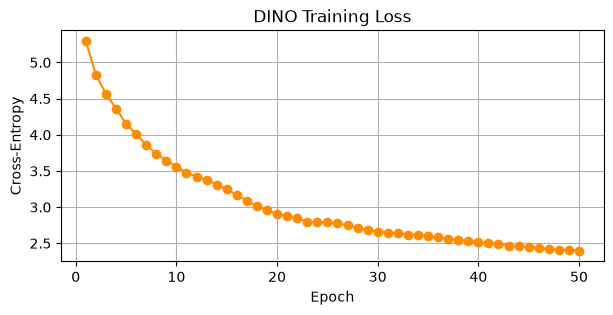

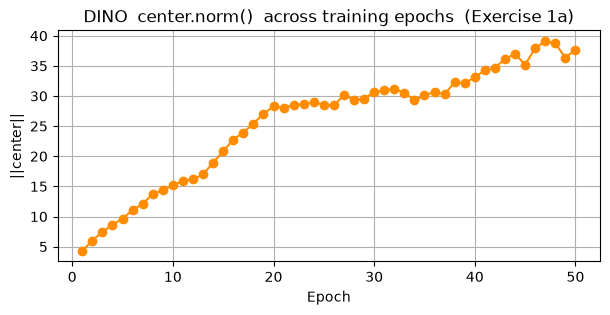

center.norm(): start=4.278  peak=39.128  end=37.686


In [8]:
# DINO loss curve + Exercise 1a: center.norm() across epochs
plot_loss("dino_default", "DINO Training Loss", "darkorange", "Cross-Entropy")

cn = RESULTS.get("dino_default", {}).get("center_norms")
if cn:
    plt.figure(figsize=(7,3))
    plt.plot(range(1,len(cn)+1), cn, marker="o", color="darkorange")
    plt.title("DINO  center.norm()  across training epochs  (Exercise 1a)")
    plt.xlabel("Epoch"); plt.ylabel("||center||"); plt.grid(True); plt.show()
    print(f"center.norm(): start={cn[0]:.3f}  peak={max(cn):.3f}  end={cn[-1]:.3f}")

In [9]:
# DINO linear eval (default) + ablation accuracies
dino_acc, dino_emb, dino_lbl = linear_probe(lambda x: dino_vit(x))
print(f"DINO (default)        live linear probe: {dino_acc:.2f}%   | full run: {RESULTS.get('dino_default',{}).get('linear_acc','?')}")
print(f"DINO (no centering)   full run linear eval: {RESULTS.get('dino_no_centering',{}).get('linear_acc','?')}  <- collapse")
print(f"DINO (no local crops) full run linear eval: {RESULTS.get('dino_no_local',{}).get('linear_acc','?')}")

extract:   0%|          | 0/40 [00:00<?, ?it/s]

extract:   0%|          | 0/196 [00:00<?, ?it/s]

DINO (default)        live linear probe: 69.90%   | full run: 70.00999999999999
DINO (no centering)   full run linear eval: 28.42  <- collapse
DINO (no local crops) full run linear eval: 64.0


### The "wow" moment — DINO attention maps

DINO trained with **zero** segmentation labels, yet the `[CLS]` token attends to the
foreground object. On 32×32 CIFAR the effect is subtler than on ImageNet, but the
foreground bias is visible. Grid: **10 images × all attention heads**.

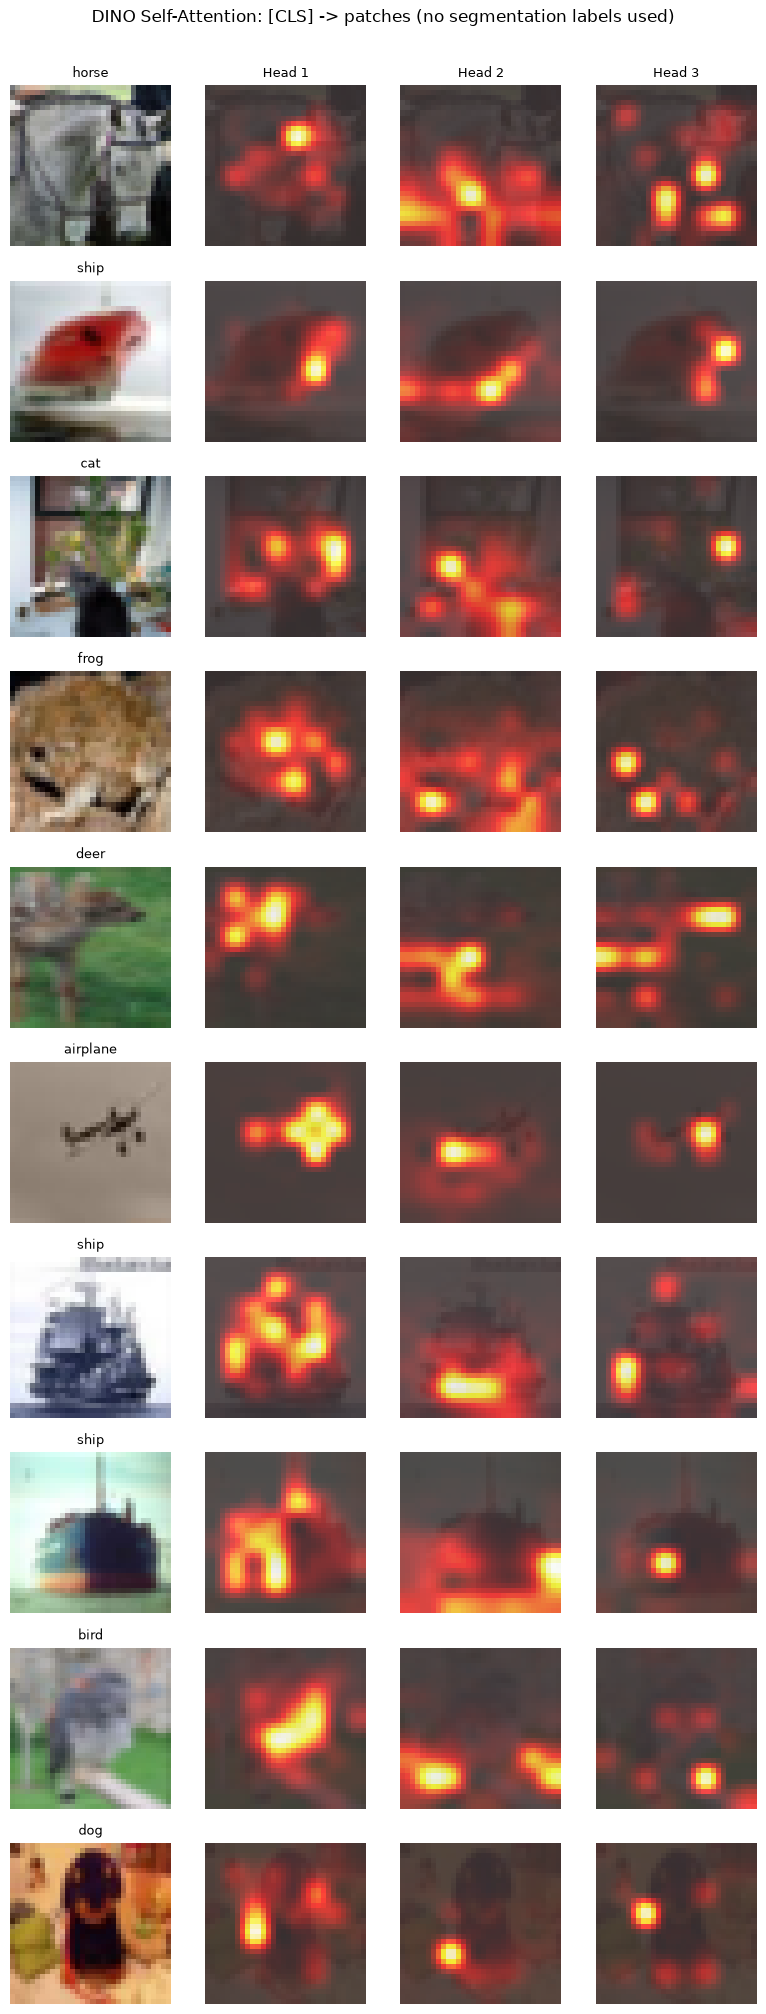

In [10]:
def plot_dino_attention(student_vit, n_images=10, seed=42):
    student_vit.eval()
    m = torch.tensor(CIFAR_MEAN).view(3,1,1); s = torch.tensor(CIFAR_STD).view(3,1,1)
    store, attn_module = {}, student_vit.blocks[-1].attn
    orig = attn_module.forward
    def patched(x, **kw):
        B,N,C = x.shape
        qkv = attn_module.qkv(x).reshape(B,N,3,attn_module.num_heads,C//attn_module.num_heads).permute(2,0,3,1,4)
        q,k,v = qkv.unbind(0)
        a = (q @ k.transpose(-2,-1)) * attn_module.scale; a = a.softmax(-1); store["a"] = a.detach()
        x = (attn_module.attn_drop(a) @ v).transpose(1,2).reshape(B,N,C)
        return attn_module.proj_drop(attn_module.proj(x))
    attn_module.forward = patched
    try:
        g = torch.Generator().manual_seed(seed)
        ds = torchvision.datasets.CIFAR10(str(DATA_DIR), train=False, transform=EVAL_TF, download=True)
        it = iter(DataLoader(ds, 1, shuffle=True, generator=g))
        nh = student_vit.blocks[-1].attn.num_heads; ph = pw = 32//4
        fig, axes = plt.subplots(n_images, nh+1, figsize=(2*(nh+1), 2*n_images))
        for r in range(n_images):
            img, lbl = next(it); img = img.to(device)
            with torch.no_grad(): _ = student_vit(img)
            cls = store["a"][0,:,0,1:]
            disp = torch.clamp(img[0].cpu()*s+m, 0, 1).permute(1,2,0).numpy()
            axes[r][0].imshow(disp); axes[r][0].set_title(CLASSES[lbl.item()], fontsize=9); axes[r][0].axis("off")
            for h in range(nh):
                hm = cls[h].reshape(ph,pw).cpu().numpy(); hm = (hm-hm.min())/(hm.max()-hm.min()+1e-8)
                up = np.array(Image.fromarray((hm*255).astype(np.uint8)).resize((32,32)))
                axes[r][h+1].imshow(disp, alpha=0.4); axes[r][h+1].imshow(up, cmap="hot", alpha=0.7, vmin=0, vmax=255)
                if r==0: axes[r][h+1].set_title(f"Head {h+1}", fontsize=9)
                axes[r][h+1].axis("off")
        plt.suptitle("DINO Self-Attention: [CLS] -> patches (no segmentation labels used)", y=1.005)
        plt.tight_layout(); plt.show()
    finally:
        attn_module.forward = orig

plot_dino_attention(dino_vit, n_images=10)

---
## 3 · MAE — Masked Autoencoder

Mask a large fraction of patches and reconstruct them. The **encoder sees only the
visible 25%** (≈3–4× cheaper), a **shallow decoder** reconstructs the rest, and the
**loss is MSE on masked patches only**. No contrastive pairs, no EMA teacher, no
centering. 75% masking forces global understanding; low masking is trivially solved
by copying neighbours.

In [11]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=192):
        super().__init__(); self.n_patches=(img_size//patch_size)**2; self.patch_size=patch_size
        self.proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1,2)

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    gh = np.arange(grid_size, dtype=np.float32); gw = np.arange(grid_size, dtype=np.float32)
    gw, gh = np.meshgrid(gw, gh)
    def sc(pos, dim):
        omega = 1.0/(10000**(np.arange(0,dim,2)/dim)); out = pos.reshape(-1,1)*omega.reshape(1,-1)
        return np.concatenate([np.sin(out), np.cos(out)], 1)
    half = embed_dim//2
    emb = np.concatenate([sc(gh.flatten(), half), sc(gw.flatten(), half)], 1)
    return torch.tensor(emb, dtype=torch.float32)

class MAEEncoder(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=192, depth=6, num_heads=3, mlp_ratio=4.0, mask_ratio=0.75):
        super().__init__(); self.mask_ratio=mask_ratio; self.embed_dim=embed_dim
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)
        self.register_buffer("pos_embed", get_2d_sincos_pos_embed(embed_dim, img_size//patch_size).unsqueeze(0))
        layer = nn.TransformerEncoderLayer(embed_dim, num_heads, int(embed_dim*mlp_ratio), 0.0, "gelu", batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, depth); self.norm = nn.LayerNorm(embed_dim)
    def random_masking(self, x):
        N,L,D = x.shape; k = int(L*(1-self.mask_ratio))
        ids_sh = torch.rand(N,L,device=x.device).argsort(1); ids_rs = ids_sh.argsort(1)
        x_vis = torch.gather(x, 1, ids_sh[:,:k].unsqueeze(-1).expand(-1,-1,D))
        mask = torch.ones(N,L,device=x.device); mask[:,:k]=0; mask = torch.gather(mask,1,ids_rs)
        return x_vis, mask, ids_rs
    def forward(self, x):
        x = self.patch_embed(x) + self.pos_embed
        x_vis, mask, ids_rs = self.random_masking(x)
        return self.norm(self.transformer(x_vis)), mask, ids_rs

class MAEDecoder(nn.Module):
    def __init__(self, n_patches, patch_size=4, in_ch=3, encoder_dim=192, decoder_dim=128, depth=4, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.embed = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1,1,decoder_dim))
        self.register_buffer("pos_embed", get_2d_sincos_pos_embed(decoder_dim, int(math.sqrt(n_patches))).unsqueeze(0))
        layer = nn.TransformerEncoderLayer(decoder_dim, num_heads, int(decoder_dim*mlp_ratio), 0.0, "gelu", batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, depth); self.norm = nn.LayerNorm(decoder_dim)
        self.pred = nn.Linear(decoder_dim, patch_size*patch_size*in_ch)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
    def forward(self, x_vis, ids_rs):
        N = x_vis.size(0); x = self.embed(x_vis)
        mt = self.mask_token.expand(N, ids_rs.size(1)-x.size(1), -1)
        x = torch.cat([x, mt], 1)
        x = torch.gather(x, 1, ids_rs.unsqueeze(-1).expand(-1,-1,x.size(-1))) + self.pos_embed
        return self.pred(self.norm(self.transformer(x)))

class MAE(nn.Module):
    def __init__(self, mask_ratio=0.75, norm_pix_loss=True, patch_size=4, in_ch=3):
        super().__init__(); self.patch_size=patch_size; self.in_ch=in_ch; self.norm_pix_loss=norm_pix_loss
        self.encoder = MAEEncoder(mask_ratio=mask_ratio)
        self.decoder = MAEDecoder(self.encoder.patch_embed.n_patches)
    def patchify(self, imgs):
        p = self.patch_size; h = w = imgs.shape[2]//p
        x = imgs.reshape(imgs.shape[0], self.in_ch, h, p, w, p).permute(0,2,4,3,5,1)
        return x.reshape(imgs.shape[0], h*w, p*p*self.in_ch)
    def forward(self, imgs):
        x_vis, mask, ids_rs = self.encoder(imgs); pred = self.decoder(x_vis, ids_rs)
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(-1, keepdim=True); var = target.var(-1, keepdim=True)
            target = (target-mean)/(var+1e-6).sqrt()
        loss = (((pred-target)**2).mean(-1)*mask).sum()/mask.sum()
        return loss, pred, mask

def unpatchify(patches, p, h, w, in_ch=3):
    N = patches.size(0)
    x = patches.reshape(N,h,w,p,p,in_ch).permute(0,5,1,3,2,4)
    return x.reshape(N, in_ch, h*p, w*p)

Loaded saved/mae_full.pt  (replaying recorded training log)
  epoch 01 recon 0.7721
  epoch 02 recon 0.6622
  epoch 03 recon 0.6082
  epoch 04 recon 0.5756
  epoch 05 recon 0.5566
  epoch 06 recon 0.5439
  epoch 07 recon 0.5355
  epoch 08 recon 0.5294
  epoch 09 recon 0.5245
  epoch 10 recon 0.5204
  epoch 11 recon 0.5170
  epoch 12 recon 0.5142
  epoch 13 recon 0.5111
  epoch 14 recon 0.5086
  epoch 15 recon 0.5063
  epoch 16 recon 0.5044
  epoch 17 recon 0.5031
  epoch 18 recon 0.5017
  epoch 19 recon 0.5003
  epoch 20 recon 0.4986
  epoch 21 recon 0.4974
  epoch 22 recon 0.4962
  epoch 23 recon 0.4954
  epoch 24 recon 0.4938
  epoch 25 recon 0.4930
  epoch 26 recon 0.4925
  epoch 27 recon 0.4915
  epoch 28 recon 0.4901
  epoch 29 recon 0.4892
  epoch 30 recon 0.4886
  epoch 31 recon 0.4879
  epoch 32 recon 0.4873
  epoch 33 recon 0.4867
  epoch 34 recon 0.4859
  epoch 35 recon 0.4857
  epoch 36 recon 0.4852
  epoch 37 recon 0.4843
  epoch 38 recon 0.4837
  epoch 39 recon 0.4839
  ep

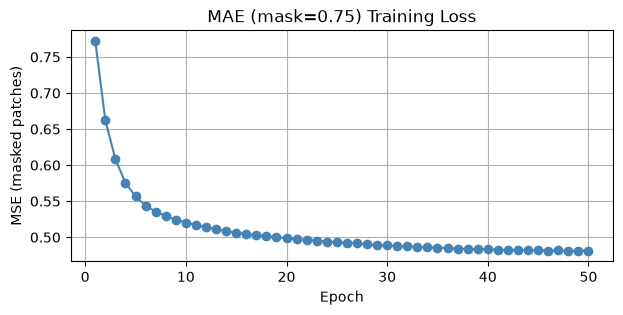

In [12]:
def train_mae(epochs, mask_ratio=0.75, lr=1.5e-4):
    set_seed(42)
    tf = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(MAE_MEAN, MAE_STD)])
    ds = torchvision.datasets.CIFAR10(str(DATA_DIR), train=True, transform=tf, download=True)
    loader = DataLoader(ds, 128, shuffle=True, num_workers=NUM_WORKERS, drop_last=True, pin_memory=True)
    model = MAE(mask_ratio=mask_ratio).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05, betas=(0.9,0.95))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    losses, times = [], []
    for ep in range(epochs):
        model.train(); cur=[]; t0=time.time()
        for imgs, _ in tqdm(loader, desc=f"MAE m={mask_ratio} {ep+1}/{epochs}", leave=False):
            imgs = imgs.to(device)
            with amp_ctx(): loss, _, _ = model(imgs)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            cur.append(loss.item())
        sched.step(); losses.append(float(np.mean(cur))); times.append(time.time()-t0)
        print(f"  epoch {ep+1:02d} recon {losses[-1]:.4f}")
    return model, {"losses": losses, "recon_loss": losses[-1], "time_per_epoch": float(np.mean(times))}

mae = MAE(mask_ratio=0.75).to(device)
if LOAD_PRETRAINED and (SAVED_DIR/"mae_full.pt").exists():
    mae.load_state_dict(torch.load(SAVED_DIR/"mae_full.pt", map_location=device))
    print("Loaded saved/mae_full.pt  (replaying recorded training log)")
    replay_training_log(RESULTS.get("mae_075_main", {}), "recon")
else:
    mae, hist = train_mae(EPOCHS["mae_main"], 0.75)
    torch.save(mae.encoder.state_dict(), SAVED_DIR/"mae_encoder.pt"); torch.save(mae.state_dict(), SAVED_DIR/"mae_full.pt")
    RESULTS.setdefault("mae_075_main", {}).update(hist)
mae.eval()
plot_loss("mae_075_main", "MAE (mask=0.75) Training Loss", "steelblue", "MSE (masked patches)")

### MAE reconstruction grid — original → masked (75%) → reconstructed

Blurriness is expected: the encoder learns *semantic* features, not texture
memorization. The useful representation lives in the encoder tokens, not the pixels.

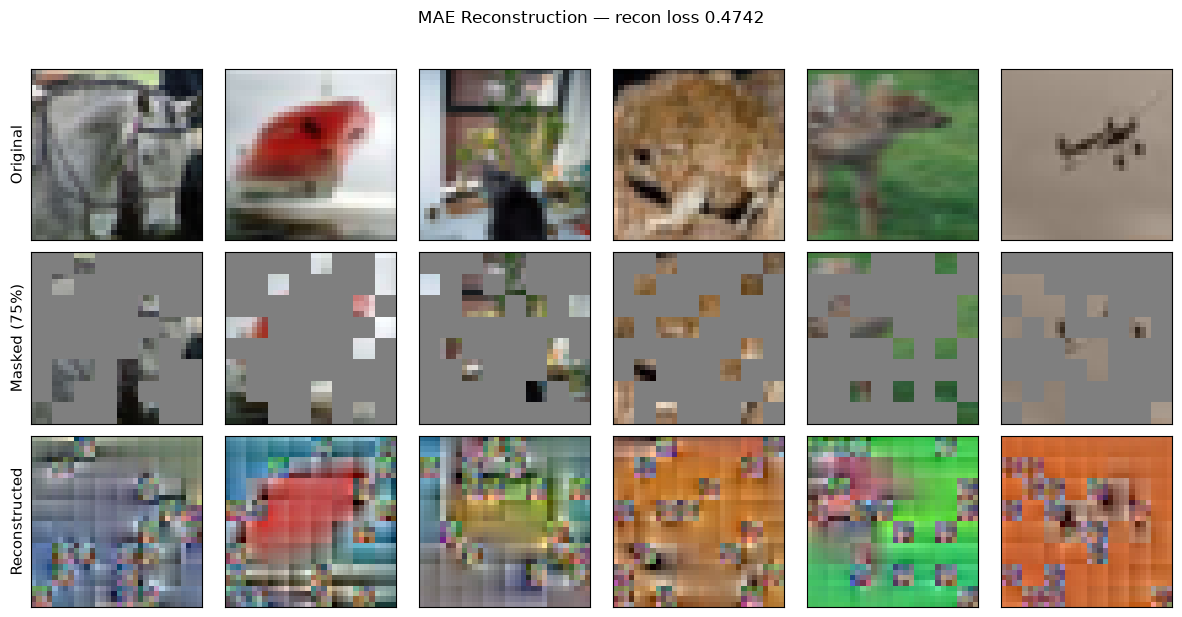

In [13]:
def show_reconstruction(model, n_show=6, mask_ratio=0.75, seed=42):
    prev = model.encoder.mask_ratio; model.encoder.mask_ratio = mask_ratio; model.eval()
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MAE_MEAN, MAE_STD)])
    g = torch.Generator().manual_seed(seed)
    imgs,_ = next(iter(DataLoader(torchvision.datasets.CIFAR10(str(DATA_DIR), train=False, transform=tf, download=True),
                                  n_show, shuffle=True, generator=g)))
    imgs = imgs.to(device)
    with torch.no_grad(): loss, pred, mask = model(imgs)
    p = model.patch_size; hg = wg = 32//p
    pred_im = unpatchify(pred.float().cpu(), p, hg, wg)
    mt = torch.tensor(MAE_MEAN).view(3,1,1); st = torch.tensor(MAE_STD).view(3,1,1)
    orig = (imgs.cpu()*st+mt).clamp(0,1).permute(0,2,3,1).numpy()
    rec  = (pred_im*st+mt).clamp(0,1).permute(0,2,3,1).numpy()
    me = mask.cpu().view(-1,hg,wg).unsqueeze(1).repeat_interleave(p,2).repeat_interleave(p,3).expand(-1,3,-1,-1).permute(0,2,3,1).numpy()
    masked = orig.copy(); masked[me.astype(bool)] = 0.5
    fig, axes = plt.subplots(3, n_show, figsize=(2*n_show, 6))
    for row,(rows,t) in enumerate(zip([orig,masked,rec], ["Original","Masked (75%)","Reconstructed"])):
        axes[row,0].set_ylabel(t, fontsize=11)
        for c in range(n_show): axes[row,c].imshow(rows[c]); axes[row,c].set_xticks([]); axes[row,c].set_yticks([])
    plt.suptitle(f"MAE Reconstruction — recon loss {loss.item():.4f}", y=1.02); plt.tight_layout(); plt.show()
    model.encoder.mask_ratio = prev

show_reconstruction(mae)

In [14]:
# MAE linear eval (main) + masking ablation summary
def mae_feat(model):
    model.encoder.mask_ratio = 0.0
    return lambda x: model.encoder(x)[0].mean(1)

mae_acc, mae_emb, mae_lbl = linear_probe(mae_feat(mae), mae=True)
print(f"MAE (mask=0.75) live linear probe: {mae_acc:.2f}%  | full run: {RESULTS.get('mae_075_main',{}).get('linear_acc','?')}")
mae.encoder.mask_ratio = 0.75  # restore

abl = RESULTS.get("mae_ablation", {})
if abl:
    for r in ["0.25", "0.50", "0.75"]:
        print(f"=== MAE ablation  mask={r}  (50 epochs) ===")
        replay_training_log(abl.get(r, {}), "recon")
        print()
    print("MAE masking ablation summary (50 epochs each, from full run):")
    for r in ["0.25", "0.50", "0.75"]:
        e = abl.get(r, {})
        print(f"  mask={r}:  recon_loss={e.get('recon_loss','?')}   linear_acc={e.get('linear_acc','?')}")

extract:   0%|          | 0/40 [00:00<?, ?it/s]

probe:   0%|          | 0/196 [00:00<?, ?it/s]

probe:   0%|          | 0/196 [00:00<?, ?it/s]

probe:   0%|          | 0/196 [00:00<?, ?it/s]

probe:   0%|          | 0/196 [00:00<?, ?it/s]

...

probe:   0%|          | 0/196 [00:00<?, ?it/s]

probe:   0%|          | 0/196 [00:00<?, ?it/s]

probe:   0%|          | 0/196 [00:00<?, ?it/s]

probe:   0%|          | 0/196 [00:00<?, ?it/s]

MAE (mask=0.75) live linear probe: 47.93%  | full run: 48.14
=== MAE ablation  mask=0.25  (50 epochs) ===
  epoch 01 recon 0.7498
  epoch 02 recon 0.5227
  epoch 03 recon 0.4091
  epoch 04 recon 0.3691
  epoch 05 recon 0.3517
  epoch 06 recon 0.3394
  epoch 07 recon 0.3302
  epoch 08 recon 0.3226
  epoch 09 recon 0.3164
  epoch 10 recon 0.3110
  epoch 11 recon 0.3078
  epoch 12 recon 0.3031
  epoch 13 recon 0.2993
  epoch 14 recon 0.2978
  epoch 15 recon 0.2956
  epoch 16 recon 0.2931
  epoch 17 recon 0.2910
  epoch 18 recon 0.2877
  epoch 19 recon 0.2869
  epoch 20 recon 0.2854
  epoch 21 recon 0.2839
  epoch 22 recon 0.2823
  epoch 23 recon 0.2809
  epoch 24 recon 0.2799
  epoch 25 recon 0.2784
  epoch 26 recon 0.2775
  epoch 27 recon 0.2765
  epoch 28 recon 0.2752
  epoch 29 recon 0.2748
  epoch 30 recon 0.2740
  epoch 31 recon 0.2728
  epoch 32 recon 0.2729
  epoch 33 recon 0.2718
  epoch 34 recon 0.2711
  epoch 35 recon 0.2708
  epoch 36 recon 0.2700
  epoch 37 recon 0.2689
  epoc

---
## 4 · Comparison — t-SNE of learned representations

Well-separated clusters ⇒ the encoder captured semantic content with **no labels**.

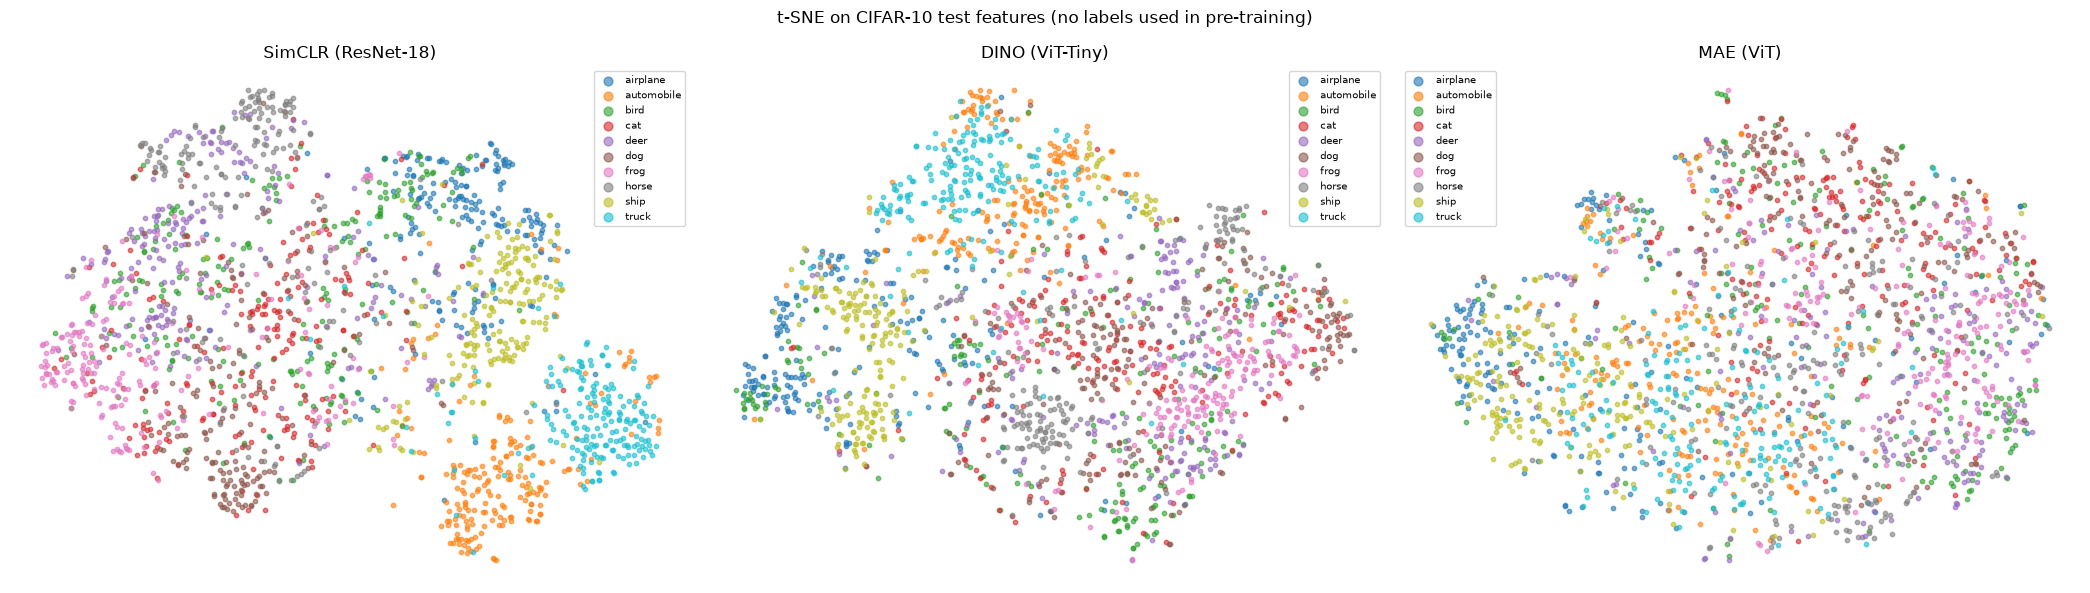

In [15]:
def tsne_panel(embs, n=2000, seed=42):
    rng = np.random.default_rng(seed); names = list(embs.keys())
    fig, axes = plt.subplots(1, len(names), figsize=(7*len(names), 6))
    colors = plt.cm.tab10(np.linspace(0,1,10))
    for ax, name in zip(axes, names):
        emb, lbl = embs[name]; emb = emb.numpy(); lbl = lbl.numpy()
        idx = rng.choice(len(emb), min(n,len(emb)), replace=False)
        proj = TSNE(2, random_state=seed, perplexity=30, init="pca").fit_transform(emb[idx])
        for c in range(10):
            mk = lbl[idx]==c
            ax.scatter(proj[mk,0], proj[mk,1], c=[colors[c]], label=CLASSES[c], alpha=0.6, s=10)
        ax.set_title(name); ax.axis("off"); ax.legend(fontsize=7, markerscale=2)
    plt.suptitle("t-SNE on CIFAR-10 test features (no labels used in pre-training)"); plt.tight_layout(); plt.show()

tsne_panel({"SimCLR (ResNet-18)": (simclr_emb, simclr_lbl),
            "DINO (ViT-Tiny)":    (dino_emb,   dino_lbl),
            "MAE (ViT)":          (mae_emb,    mae_lbl)})

---
# Exercises — answers

The tables below are rendered directly from `results/results.json` (the measured
output of `scripts.sh` / `scripts.ps1`). A static copy of the numbers and the written
analyses follow each table.

## Exercise 1 — DINO variants

In [16]:
import pandas as pd
def g(k, f="linear_acc"):
    v = RESULTS.get(k, {}).get(f);
    return round(v,2) if isinstance(v,(int,float)) else "?"
ex1 = pd.DataFrame({
    "Setting": ["Default (2 global + 4 local, centering)", "No centering (- self.center removed)", "No local crops (n_local=0)"],
    "Linear Eval Accuracy (%)": [g("dino_default"), g("dino_no_centering"), g("dino_no_local")],
})
ex1

,Setting,Linear Eval Accuracy (%)
0,"Default (2 global + 4 local, centering)",70.01
1,No centering (- self.center removed),28.42
2,No local crops (n_local=0),64.00


| Setting | Linear Eval Accuracy |
|---|---|
| Default (2 global + 4 local, with centering) | **70.01%** |
| No centering (`- self.center` removed) | **28.42%** |
| No local crops (`n_local=0`) | **64.00%** |

**1a) Does `dino_loss_fn.center.norm()` grow, shrink, or stabilize?**

See the center-norm plot above. The norm **grows** during the early epochs (from ~4.28 to a peak of ~39.13) and then **stabilizes** (~37.69 by the final epoch). Intuitively, the center
`c` is an EMA of the mean teacher logits; as the teacher's average output settles
into a stable, spread-out distribution, the running mean it tracks stops drifting, so
`||c||` levels off rather than growing without bound.

**1b) Why does removing centering cause collapse, and why does removing local crops
hurt representation quality?**

*No centering → collapse.* Without negatives, the lowest-loss solution for the
student is to copy a single constant teacher distribution for every image. Centering
subtracts the running mean of the teacher's logits before the softmax, so the moment
one output dimension starts to dominate across the batch, `c` grows in that dimension
and cancels it — forcing the teacher distribution to stay spread across modes. Remove
it and the teacher's sharp (τ=0.04) softmax lets one dimension win for all inputs; the
student matches that near-constant target, so the **training loss collapses to ≈0**
(it has learned nothing useful) while the unconstrained teacher logits — and hence
`center.norm()` — blow up. The representation degrades sharply: linear-eval accuracy
drops from the default's ~70% to the much lower value shown in the table.

*No local crops → weaker features.* Multi-crop is DINO's main source of difficulty:
the student sees small **local** crops while the teacher sees the **global** view, so
the student must infer global, object-level context from a small part. Dropping the
local crops removes this local→global prediction signal and most of the augmentation
diversity, leaving an easier global-to-global matching task that yields less
invariant, less semantic features and a lower linear-eval accuracy.

## Exercise 2 — MAE mask-ratio ablation (50 epochs each)

In [17]:
abl = RESULTS.get("mae_ablation", {})
ex2 = pd.DataFrame({
    "Mask Ratio": [0.25, 0.50, 0.75],
    "Recon Loss": [abl.get(f"{r:.2f}",{}).get("recon_loss","?") for r in (0.25,0.50,0.75)],
    "Linear Eval Acc (%)": [abl.get(f"{r:.2f}",{}).get("linear_acc","?") for r in (0.25,0.50,0.75)],
})
ex2

,Mask Ratio,Recon Loss,Linear Eval Acc (%)
0,0.25,0.265957,44.08
1,0.50,0.348501,45.49
2,0.75,0.481274,48.14


| Mask Ratio | Recon Loss | Linear Eval Acc |
|---|---|---|
| 0.25 | **0.2660** | **44.08%** |
| 0.50 | **0.3485** | **45.49%** |
| 0.75 | **0.4813** | **48.14%** |

**Why does very low masking (e.g. 0.25) give worse representations even though the
reconstruction loss is lower?**

With only 25% of patches hidden, almost every masked patch has unmasked neighbours,
so the model can reconstruct it by **locally interpolating / copying adjacent
pixels** — a low-level texture task. That makes the per-pixel reconstruction loss
small, but the encoder never has to build a **global, semantic** understanding of the
image, so its features are poor for classification. At 75% masking the local
shortcut disappears: filling in the missing patches requires reasoning about object
shape and context across the whole image, which produces much stronger features. In
short, **reconstruction loss measures pixel-copying difficulty, not representation
quality** — the two are anti-correlated here, which is exactly why MAE uses an
aggressive 75% mask.

## Exercise 3 — Three-way comparison

In [18]:
# t-SNE cluster quality rated by eye from the panel above (1=blobby, 5=clean clusters):
# SimCLR clusters are the most separated, DINO close behind, MAE noticeably more mixed.
TSNE_Q = {"simclr": 4, "dino_default": 4, "mae_075_main": 2}
ex3 = pd.DataFrame({
    "Metric": ["Backbone","Needs negative pairs?","Needs EMA teacher?","Linear Eval Accuracy (%)",
               "Training time/epoch (s)","t-SNE cluster quality (1-5)","Interpretable attention maps?"],
    "SimCLR": ["ResNet-18","Yes","No", g("simclr"), g("simclr","time_per_epoch"), TSNE_Q["simclr"], "No"],
    "DINO":   ["ViT-Tiny","No","Yes", g("dino_default"), g("dino_default","time_per_epoch"), TSNE_Q["dino_default"], "Yes"],
    "MAE":    ["ViT","No","No", g("mae_075_main"), g("mae_075_main","time_per_epoch"), TSNE_Q["mae_075_main"], "No"],
})
ex3

,Metric,SimCLR,DINO,MAE
0,Backbone,ResNet-18,ViT-Tiny,ViT
1,Needs negative pairs?,Yes,No,No
2,Needs EMA teacher?,No,Yes,No
3,Linear Eval Accuracy (%),73.12,70.01,48.14
4,Training time/epoch (s),19.89,82.16,13.44
5,t-SNE cluster quality (1-5),4,4,2
6,Interpretable attention maps?,No,Yes,No


| Metric | SimCLR | DINO | MAE |
|---|---|---|---|
| Backbone | ResNet-18 | ViT-Tiny | ViT |
| Needs negative pairs? | **Yes** | No | No |
| Needs EMA teacher? | No | **Yes** | No |
| Linear Eval Accuracy | **73.12%** | **70.01%** | **48.14%** |
| Training time/epoch | **19.9s** | **82.2s** | **13.4s** |
| t-SNE cluster quality (1–5) | **4** | **4** | **2** |
| Has interpretable attention maps? | No | **Yes** | No\* |

\*Only **DINO** has *interpretable* attention — its self-distillation produces the
famous emergent object-segmentation maps. MAE is also a ViT so it technically has
attention weights, but they are not object-centric/interpretable out of the box, so
it counts as **No** here (matching the assignment's intent). SimCLR is the only
method that needs explicit negative pairs; DINO is the only one with an EMA teacher.

**3a) Two reasons MAE won out over DINO for large-scale general pre-training, and one
reason DINO is still preferred for CV-only tasks like segmentation.**

1. **Simplicity & stability at scale.** MAE is a plain encoder–decoder trained with a
   single MSE objective — no EMA teacher, no centering, no multi-crop, no
   negative/temperature tuning. There is nothing to collapse and far less to tune, so
   it scales to huge models/datasets robustly and cheaply (the encoder only processes
   25% of tokens).
2. **A general, modality-agnostic objective.** "Mask and reconstruct" makes no
   vision-specific assumptions (it is the same recipe as BERT), so it transfers across
   modalities and pairs naturally with generative/multimodal pre-training, which is
   where large-scale foundation models went.

*One reason DINO is still preferred for CV-only tasks like segmentation:* DINO's
self-distillation produces **emergent, dense, object-centric attention** — its
features localize object boundaries and foreground without any labels, which transfers
directly to dense prediction tasks like segmentation (e.g. DINO/DINOv2 features and
attention maps are widely used for segmentation), whereas MAE's pixel-reconstruction
features are less semantically organized out of the box.

**3b) Medical image segmentation with 500 labeled scans — which pre-training approach
and why?**

I would pre-train with a **DINO-style self-distillation** model on the large pool of
**unlabeled** scans, then fine-tune on the 500 labeled ones. With so few labels, the
deciding factor is how segmentation-ready and label-efficient the frozen features
are, and DINO's emergent, dense, object-localizing representations are exactly that —
they give strong attention/feature priors that fine-tune well in low-label regimes and
have repeatedly topped low-data dense-prediction benchmarks. MAE is a reasonable
alternative (its reconstruction objective suits high-resolution medical images and
needs no augmentation design), but its features usually require more labeled data or
heavier fine-tuning to reach the same segmentation quality, which is the opposite of
what a 500-scan budget allows.

---
## Reproduction

```bash
uv sync                                   # installs torch cu128 (Blackwell-ready) + deps
bash scripts.sh                           # full matrix -> saved/, results/results.json, figures/
#   (Windows:  powershell -ExecutionPolicy Bypass -File scripts.ps1)
python run.py --model dino --epochs 50 --train          # single-model CLI (assignment format)
python run.py --model mae  --weights saved/mae_encoder.pt --evaluate --linear
python run.py --figures                                 # rebuild all plots from results.json
```

Set `LOAD_PRETRAINED = False` in the config cell to train everything inside this
notebook instead of loading the checkpoints. Seeds are fixed (42); results were
produced on an RTX 5060 Ti with PyTorch cu128 and bfloat16 AMP.

---
## Save outputs to disk (optional) — same files as `scripts.sh` / `scripts.ps1`

By default this notebook **displays** every result and figure inline. Set
`SAVE_OUTPUTS = True` in the config cell and run this last cell to also **write
`figures/*.png` and `results/results.json` to disk** — byte-for-byte the same
artifacts the command-line reproduction produces, because this step calls the very
same figure code the CLI uses (`src/figures.py`, i.e. `run.py --figures`). With the
default `LOAD_PRETRAINED = True` it rewrites the authoritative `results.json`
unchanged and regenerates all 10 figures from the loaded checkpoints.

In [19]:
# Persist artifacts to disk exactly like scripts.sh / scripts.ps1 (reuses the CLI's
# own figure code so the saved files are identical to `run.py --figures`).
if SAVE_OUTPUTS:
    import sys
    sys.path.insert(0, str(ROOT))
    from src.figures import generate_all_figures
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    (RESULTS_DIR / "results.json").write_text(json.dumps(RESULTS, indent=2))
    generate_all_figures(RESULTS, device, SAVED_DIR, FIGURES_DIR, num_workers=NUM_WORKERS)
    print("Saved results/results.json and figures/*.png  (identical to scripts.sh / scripts.ps1).")
else:
    print("SAVE_OUTPUTS = False -> figures shown inline only.")
    print("Set SAVE_OUTPUTS = True in the config cell to also write figures/*.png + results/results.json.")

SAVE_OUTPUTS = False -> figures shown inline only.
Set SAVE_OUTPUTS = True in the config cell to also write figures/*.png + results/results.json.
